# Práctico 3 — Aprendizaje Supervisado y No Supervisado
## DiploDatos 2026 · Ciencia de Datos Aplicada al Fútbol

**Objetivos de aprendizaje**
- Implementar el framework VAEP (Valuing Actions by Estimating Probabilities) completo
- Implementar y comparar el framework xT (Expected Threat)
- Usar XGBoost y LightGBM para predicción de valor de acciones
- Interpretar modelos con SHAP (SHapley Additive exPlanations)
- Aplicar clustering (K-Means + UMAP) para identificar perfiles de jugadores
- Construir un sistema de scouting basado en similitud

**Referencias clave**:
- Decroos et al. (2019) *Actions Speak Louder than Goals: Valuing Player Actions in Football*
- Van Roy et al. (2020) *Valuing on-the-ball actions in soccer: a critical comparison of XT and VAEP*
- Singh (2019) *Introducing Expected Threat* (blog)

---

In [1]:
# Instalación de dependencias
#!pip install socceraction xgboost lightgbm shap umap-learn scikit-learn pandas numpy matplotlib mplsoccer

In [ ]:
import warnings
import numpy as np
import pandas as pd
import codecs
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from mplsoccer import Pitch, VerticalPitch

# ML
import xgboost as xgb
import lightgbm as lgb
import shap
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import umap

# socceraction
import socceraction.spadl as spadl
import socceraction.vaep.features as features
import socceraction.vaep.labels as labels
import socceraction.vaep.formula as vaep_formula

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✓ Librerías cargadas')

✓ Librerías cargadas


In [13]:
# Cargamos el dataset curado del Práctico 2
from pathlib import Path

dataset_path = Path("./spadl_curado_PL_2017.parquet")
if not dataset_path.exists():
    dataset_path = Path("../data/processed/spadl_curado_PL_2017.parquet")
if not dataset_path.exists():
    dataset_path = Path("spadl_curado_PL_2017.parquet")

df_clean = pd.read_parquet(dataset_path)
print(f"Dataset cargado: {df_clean.shape}")
print(f"Partidos únicos: {df_clean['game_id'].nunique()} | Jugadores únicos: {df_clean['player_id'].nunique()}")


Dataset cargado: (474866, 27)
Partidos únicos: 380 | Jugadores únicos: 557


In [ ]:
# Ajustamos codificacion de caracteres especiales
df_clean['short_name']=df_clean['short_name'].apply(lambda x: codecs.decode(x, 'unicode_escape') if isinstance(x, str) else x)
df_clean['team_name']=df_clean['team_name'].apply(lambda x: codecs.decode(x, 'unicode_escape') if isinstance(x, str) else x)

## PARTE A — Aprendizaje Supervisado

## 1. Framework xT (Expected Threat)

xT fue propuesto por Karun Singh en 2019. La idea central: el campo se divide en zonas y
a cada zona se le asigna un valor que refleja cuán amenazante es estar ahí.

**Formalmente**: xT(z) = P(shoot|z) × P(goal|shoot, z) + P(move|z) × Σ P(move to z'|move, z) × xT(z')

Es un modelo iterativo que converge en ~10 iteraciones.

In [15]:
def compute_xt_grid(df_actions: pd.DataFrame, M: int = 16, N: int = 12, 
                    n_iter: int = 10) -> tuple:
    """
    Implementación del modelo xT (Expected Threat).
    
    Parámetros
    ----------
    df_actions : DataFrame SPADL
    M, N       : dimensiones de la grilla (M columnas, N filas)
    n_iter     : iteraciones hasta convergencia
    
    Retorna
    -------
    (xT, pct_shoot, pct_goal) : arrays (M, N) con valores de amenaza por zona
    """
    # Asignamos cada acción a su celda de grilla
    df = df_actions.copy()
    df["cell_x"] = np.clip((df["start_x"] / 105 * M).astype(int), 0, M-1)
    df["cell_y"] = np.clip((df["start_y"] / 68 * N).astype(int), 0, N-1)
    df["end_cell_x"] = np.clip((df["end_x"].fillna(df["start_x"]) / 105 * M).astype(int), 0, M-1)
    df["end_cell_y"] = np.clip((df["end_y"].fillna(df["start_y"]) / 68 * N).astype(int), 0, N-1)
    
    # Máscara de tiros
    shot_names = ["shot", "shot_penalty", "penalty_shot", "shot_freekick", "freekick_shot"]
    shots = df[df["type_name"].isin(shot_names)]
    moves = df[~df["type_name"].isin(shot_names)]
    
    pct_shoot = np.zeros((M, N))
    pct_goal  = np.zeros((M, N))
    pct_move  = np.zeros((M, N))
    
    for (cx, cy), group in df.groupby(["cell_x", "cell_y"]):
        n_total = len(group)
        n_shots = len(group[group["type_name"].isin(shot_names)])
        n_goals = len(group[(group["type_name"].isin(shot_names)) & (group["result_name"] == "success")])
        pct_shoot[cx, cy] = n_shots / max(n_total, 1)
        pct_goal[cx, cy]  = n_goals / max(n_shots, 1)
        pct_move[cx, cy]  = 1 - pct_shoot[cx, cy]

    # Matriz de transición de movimientos P(z' | z) optimizada
    transition = np.zeros((M, N, M, N))
    total_from_dict = moves.groupby(["cell_x", "cell_y"]).size().to_dict()
    for (cx, cy, ecx, ecy), count in moves.groupby(
        ["cell_x", "cell_y", "end_cell_x", "end_cell_y"]
    ).size().items():
        tf = total_from_dict.get((cx, cy), 0)
        if tf > 0:
            transition[cx, cy, ecx, ecy] = count / tf

    # Iteración de valor (Value Iteration)
    xT = np.zeros((M, N))
    for iteration in range(n_iter):
        xT_prev = xT.copy()
        # Valor de mover = suma ponderada de xT de destinos
        move_value = np.einsum("xyzw,zw->xy", transition, xT_prev)
        xT = pct_shoot * pct_goal + pct_move * move_value
        delta = np.max(np.abs(xT - xT_prev))
        if (iteration + 1) % 2 == 0:
            print(f"  Iteración {iteration+1}: Δmax = {delta:.6f}")

    return xT, pct_shoot, pct_goal

print("Computando grilla xT (M=16, N=12)...")
xT_grid, pshot_grid, pgoal_grid = compute_xt_grid(df_clean, M=16, N=12, n_iter=10)


Computando grilla xT (M=16, N=12)...
  Iteración 2: Δmax = 0.015278
  Iteración 4: Δmax = 0.004045
  Iteración 6: Δmax = 0.002423
  Iteración 8: Δmax = 0.001879
  Iteración 10: Δmax = 0.001709


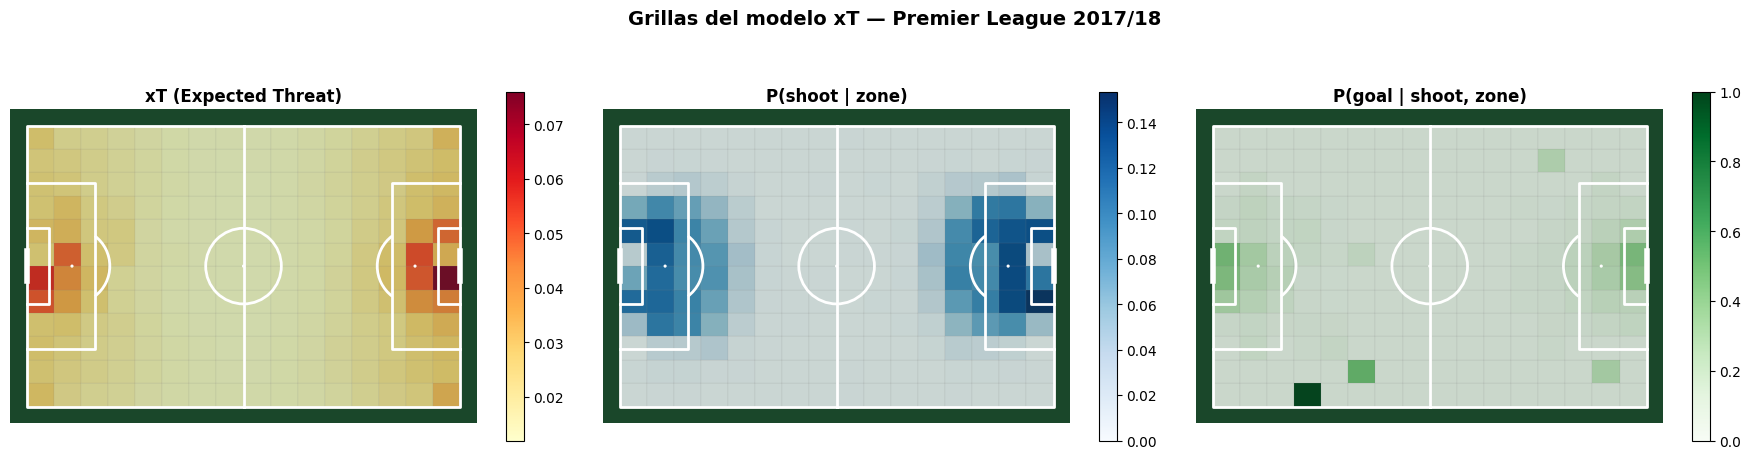

In [16]:
# Visualización de la grilla xT
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['xT (Expected Threat)', 'P(shoot | zone)', 'P(goal | shoot, zone)']
grids  = [xT_grid, pshot_grid, pgoal_grid]
cmaps  = ['YlOrRd', 'Blues', 'Greens']

for ax, title, grid, cmap in zip(axes, titles, grids, cmaps):
    pitch = Pitch(pitch_type='custom', pitch_length=105, pitch_width=68,
                  pitch_color='#1a472a', line_color='white', line_zorder=2)
    pitch.draw(ax=ax)
    M, N = grid.shape
    # Dibujamos cada celda
    norm = mcolors.Normalize(vmin=grid.min(), vmax=grid.max())
    cmap_obj = plt.get_cmap(cmap)
    for i in range(M):
        for j in range(N):
            x0 = i * 105 / M
            y0 = j * 68 / N
            rect = plt.Rectangle(
                (x0, y0), 105/M, 68/N,
                linewidth=0.1, edgecolor='gray',
                facecolor=cmap_obj(norm(grid[i, j])),
                alpha=0.8
            )
            ax.add_patch(rect)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    plt.colorbar(sm, ax=ax, shrink=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Grillas del modelo xT — Premier League 2017/18', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# Asignamos el valor xT a cada acción
M, N = xT_grid.shape

df_clean["cell_x"]     = np.clip((df_clean["start_x"] / 105 * M).astype(int), 0, M-1)
df_clean["cell_y"]     = np.clip((df_clean["start_y"] / 68 * N).astype(int), 0, N-1)
df_clean["end_cell_x"] = np.clip((df_clean["end_x"].fillna(df_clean["start_x"]) / 105 * M).astype(int), 0, M-1)
df_clean["end_cell_y"] = np.clip((df_clean["end_y"].fillna(df_clean["start_y"]) / 68 * N).astype(int), 0, N-1)

# Indexación vectorizada de NumPy (alta performance)
df_clean["xT_start"] = xT_grid[df_clean["cell_x"].values, df_clean["cell_y"].values]
df_clean["xT_end"]   = xT_grid[df_clean["end_cell_x"].values, df_clean["end_cell_y"].values]
df_clean["xT_added"] = df_clean["xT_end"] - df_clean["xT_start"]

# Solo para acciones que mueven el balón (no tiros)
shot_names = ["shot", "shot_penalty", "penalty_shot", "shot_freekick", "freekick_shot"]
mask_moves = ~df_clean["type_name"].isin(shot_names)

print("Top 10 acciones por xT añadido (positivo):")
cols_show = ["game_id", "player_id", "short_name", "type_name", "xT_start", "xT_end", "xT_added"]
cols_show = [c for c in cols_show if c in df_clean.columns]
print(df_clean[mask_moves].nlargest(10, "xT_added")[cols_show].to_string(index=False))


Top 10 acciones por xT añadido (positivo):
 game_id  player_id     short_name        type_name  xT_start   xT_end  xT_added
 2565558      40770   Willian José          dribble  0.012132 0.075992  0.063860
 2565781       3642          Ramis             pass  0.013098 0.075992  0.062894
 2565770      56025 M. Krohn-Dehli             pass  0.013611 0.075992  0.062380
 2565592       5542    Dani García             pass  0.013625 0.075992  0.062367
 2565867       3306   Sergio Ramos             pass  0.013710 0.075992  0.062282
 2565866       3280      É. Banega freekick_crossed  0.013735 0.075992  0.062257
 2565734      93000        Antunes             pass  0.013772 0.075992  0.062220
 2565587     280383      E. Bardhi freekick_crossed  0.013818 0.075992  0.062174
 2565781      20436     José Ángel            cross  0.013818 0.075992  0.062174
 2565736       3433       D. Godín             pass  0.013957 0.075992  0.062034


In [18]:
# Ranking de jugadores por xT añadido (normalizado por partido)
games_per_player = df_clean.groupby("player_id")["game_id"].nunique().reset_index()
games_per_player.columns = ["player_id", "games"]

# Diccionario para asociar short_name a cada jugador
player_names = df_clean.dropna(subset=["short_name"]).groupby("player_id")["short_name"].last().to_dict() if "short_name" in df_clean.columns else {}

xt_by_player = df_clean[mask_moves].groupby("player_id").agg(
    xT_total=("xT_added", "sum"),
    n_actions=("xT_added", "count")
).reset_index()

xt_by_player = xt_by_player.merge(games_per_player, on="player_id")
xt_by_player = xt_by_player[xt_by_player["games"] >= 10]
xt_by_player["xT_p90"] = xt_by_player["xT_total"] / xt_by_player["games"]
xt_by_player["jugador"] = xt_by_player["player_id"].map(player_names).fillna(xt_by_player["player_id"].astype(str))

print("Top 15 jugadores por xT añadido por partido:")
print(
    xt_by_player.sort_values("xT_p90", ascending=False)
    .head(15)[["player_id", "jugador", "xT_total", "n_actions", "games", "xT_p90"]]
    .to_string(index=False)
)


Top 15 jugadores por xT añadido por partido:
 player_id           jugador  xT_total  n_actions  games   xT_p90
      4379    Jonathan Viera  4.995496       1858     23 0.217195
      3359          L. Messi  7.474469       2560     36 0.207624
      4014        Pedro León  2.381005        571     12 0.198417
     20436        José Ángel  5.896669       1987     30 0.196556
      3280         É. Banega  5.746618       2746     31 0.185375
     14723          T. Kroos  4.643855       2456     27 0.171995
    214062      Álex Granell  5.716824       2271     34 0.168142
      3310           Marcelo  4.705665       2308     28 0.168059
      3676      Illarramendi  5.628456       3138     36 0.156346
    278289         Odriozola  5.047721       2264     35 0.144221
      3443              Koke  4.977213       2481     35 0.142206
      4780       David Juncà  1.886916        783     14 0.134780
      3384       A. Guardado  3.799049       1861     29 0.131002
      3286       Dani Parejo  4

## 2. Framework VAEP (Valuing Actions by Estimating Probabilities)

VAEP va más allá de xT al usar aprendizaje supervisado para estimar:
- **P(score)**: probabilidad de que el equipo que tiene el balón anote en los próximos 10 acciones
- **P(concede)**: probabilidad de que el equipo que tiene el balón reciba un gol en las próximas 10 acciones

El valor de una acción es: `VAEP(a) = ΔP(score) - ΔP(concede)`

In [19]:
# Generamos game states (contexto de 3 acciones previas)
print("Generando game states...")
gamestates = features.gamestates(df_clean, nb_prev_actions=3)

# Features para el modelo VAEP
feat_fns = [
    features.actiontype_onehot,
    features.result_onehot,
    features.bodypart_onehot,
    features.time,
    features.startlocation,
    features.endlocation,
    features.movement,
    features.startpolar,
    features.endpolar,
    features.team,
]

X_vaep = pd.concat(
    [fn(gamestates) for fn in feat_fns],
    axis=1
).fillna(0)

print(f"Features: {X_vaep.shape[1]} columnas x {X_vaep.shape[0]:,} acciones")


Generando game states...
Features: 143 columnas x 474,866 acciones


In [20]:
# Labels: P(score) y P(concede)
ys = pd.concat([
    labels.scores(df_clean, nr_actions=10),
    labels.concedes(df_clean, nr_actions=10)
], axis=1)

print("Distribución de labels:")
print(f"  Scoring (gol en ≤10 acciones): {ys['scores'].mean():.3%}")
print(f"  Conceding (gol en contra en ≤10): {ys['concedes'].mean():.3%}")
print(f"  Total acciones: {len(ys):,}")


Distribución de labels:
  Scoring (gol en ≤10 acciones): 1.577%
  Conceding (gol en contra en ≤10): 0.512%
  Total acciones: 474,866


In [21]:
def train_vaep_model(X: pd.DataFrame, y: pd.Series, 
                     model_type: str = "xgboost") -> tuple:
    """
    Entrena un modelo para VAEP con validación cruzada estratificada.
    
    Parámetros
    ----------
    X          : features
    y          : label (scores o concedes)
    model_type : "xgboost" o "lightgbm"
    
    Retorna
    -------
    (model, y_pred_proba, metrics)
    """
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    
    if model_type == "xgboost":
        model = xgb.XGBClassifier(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    else:  # lightgbm
        model = lgb.LGBMClassifier(
            n_estimators=100,
            max_depth=4,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        )

    # Predicciones out-of-fold
    y_pred = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]
    model.fit(X, y)  # Entrenamos en todo para inferencia y SHAP

    metrics = {
        "AUC": roc_auc_score(y, y_pred),
        "Brier": brier_score_loss(y, y_pred),
        "Base_rate": y.mean()
    }

    return model, y_pred, metrics

# Entrenamos los dos modelos VAEP
print("Entrenando modelo P(score)...")
model_score, pred_score, metrics_score = train_vaep_model(
    X_vaep, ys["scores"], model_type="xgboost"
)
print(f"  AUC={metrics_score['AUC']:.4f} | Brier={metrics_score['Brier']:.4f}")

print("Entrenando modelo P(concede)...")
model_concede, pred_concede, metrics_concede = train_vaep_model(
    X_vaep, ys["concedes"], model_type="xgboost"
)
print(f"  AUC={metrics_concede['AUC']:.4f} | Brier={metrics_concede['Brier']:.4f}")


Entrenando modelo P(score)...
  AUC=0.7404 | Brier=0.0134
Entrenando modelo P(concede)...
  AUC=0.7230 | Brier=0.0050


In [22]:
# Computamos los valores VAEP
# VAEP(a) = ΔP(score) - ΔP(concede)

df_vaep = df_clean.copy()
df_vaep["p_score"]   = pred_score
df_vaep["p_concede"] = pred_concede

# El valor se calcula como el delta respecto al estado anterior (requiere pd.Series)
values = vaep_formula.value(
    df_clean, 
    pd.Series(pred_score, index=df_clean.index), 
    pd.Series(pred_concede, index=df_clean.index)
)

df_vaep["vaep_value"] = values["vaep_value"]
df_vaep["off_value"]  = values["offensive_value"]
df_vaep["def_value"]  = values["defensive_value"]

print("Estadísticas de valor VAEP:")
print(df_vaep["vaep_value"].describe())


Estadísticas de valor VAEP:
count    474866.000000
mean          0.002957
std           0.043466
min          -0.866949
25%          -0.002630
50%           0.000951
75%           0.005374
max           1.208478
Name: vaep_value, dtype: float64


In [23]:
# Ranking de jugadores por VAEP
vaep_by_player = df_vaep.groupby("player_id").agg(
    vaep_total=("vaep_value", "sum"),
    off_total=("off_value", "sum"),
    def_total=("def_value", "sum"),
    n_actions=("vaep_value", "count")
).reset_index()

vaep_by_player = vaep_by_player.merge(games_per_player, on="player_id")
vaep_by_player = vaep_by_player[vaep_by_player["games"] >= 10]
vaep_by_player["vaep_p90"] = vaep_by_player["vaep_total"] / vaep_by_player["games"]
vaep_by_player["jugador"] = vaep_by_player["player_id"].map(player_names).fillna(vaep_by_player["player_id"].astype(str))

print("\n=== TOP 15 JUGADORES POR VAEP POR PARTIDO ===")
print(
    vaep_by_player.sort_values("vaep_p90", ascending=False)
    .head(15)[["player_id", "jugador", "vaep_total", "off_total", "def_total", "games", "vaep_p90"]]
    .to_string(index=False)
)



=== TOP 15 JUGADORES POR VAEP POR PARTIDO ===
 player_id           jugador  vaep_total  off_total  def_total  games  vaep_p90
      3359          L. Messi   31.317364  33.906672  -2.589308     36  0.869927
      3322 Cristiano Ronaldo   17.471035  19.077383  -1.606348     27  0.647075
      8278           G. Bale   14.080137  14.597382  -0.517245     26  0.541544
      3682      A. Griezmann   16.577194  16.776442  -0.199248     32  0.518037
      3840        Iago Aspas   17.004349  17.935004  -0.930654     34  0.500128
      7972         L. Suárez   16.287613  19.256255  -2.968642     33  0.493564
     25472        C. Bakambu    6.849205   7.312115  -0.462909     15  0.456614
      3676      Illarramendi   15.481583  14.767857   0.713726     36  0.430044
      3802 Philippe Coutinho    7.667049   8.171198  -0.504149     18  0.425947
     70129           Rodrigo   14.773297  15.485078  -0.711780     37  0.399278
      3791         Z. Feddal    5.814663   5.630336   0.184326     15  0.

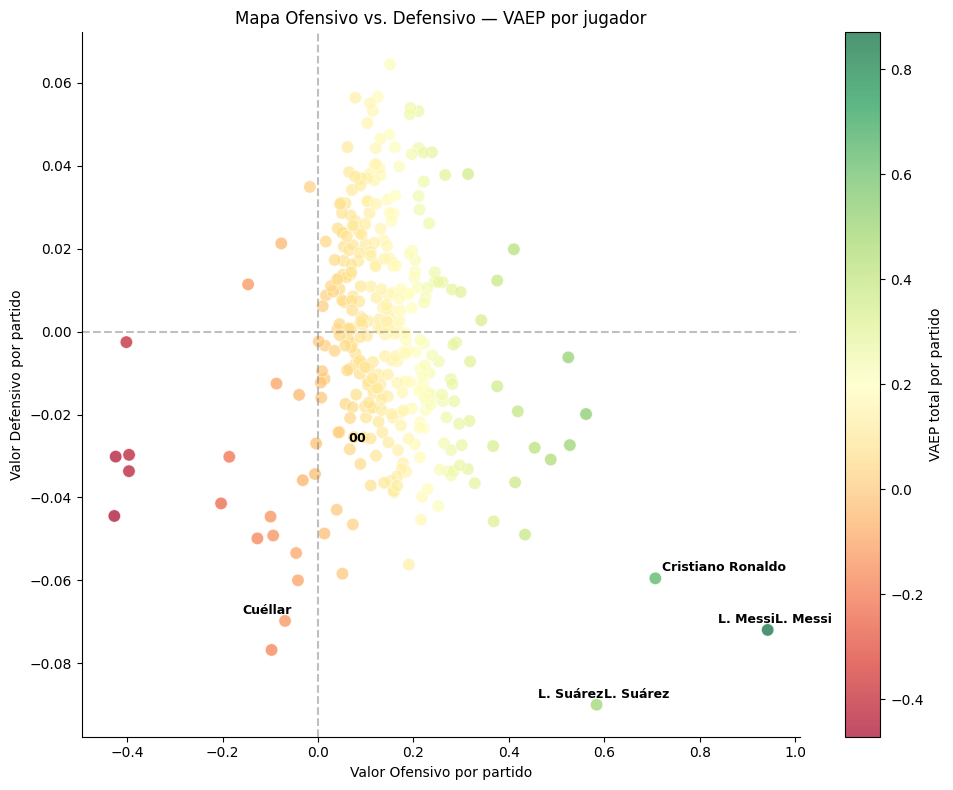

In [24]:
# Visualización: valor ofensivo vs defensivo
fig, ax = plt.subplots(figsize=(10, 8))

top_players = vaep_by_player[vaep_by_player["games"] >= 15]
scatter = ax.scatter(
    top_players["off_total"] / top_players["games"],
    top_players["def_total"] / top_players["games"],
    c=top_players["vaep_p90"],
    cmap="RdYlGn",
    s=80, alpha=0.7, edgecolors="white", linewidth=0.5
)
plt.colorbar(scatter, label="VAEP total por partido")

ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Valor Ofensivo por partido")
ax.set_ylabel("Valor Defensivo por partido")
ax.set_title("Mapa Ofensivo vs. Defensivo — VAEP por jugador")
ax.spines[["top","right"]].set_visible(False)

# Etiquetas para extremos con nombres legibles
for label, df_label, ha in [
    ("Más ofensivos", top_players.nlargest(4, "off_total"), "left"),
    ("Más defensivos", top_players.nsmallest(4, "def_total"), "right")
]:
    for _, row in df_label.iterrows():
        display_txt = row["jugador"] if pd.notna(row.get("jugador")) else str(int(row["player_id"]))
        ax.annotate(
            display_txt,
            (row["off_total"]/row["games"], row["def_total"]/row["games"]),
            xytext=(5, 5), textcoords="offset points",
            fontsize=9, fontweight="bold", ha=ha
        )

plt.tight_layout()
plt.show()


## 3. Explicabilidad con SHAP

Los modelos de gradient boosting son cajas negras. SHAP nos permite entender
la contribución de cada feature a cada predicción individual.

Calculando SHAP values...


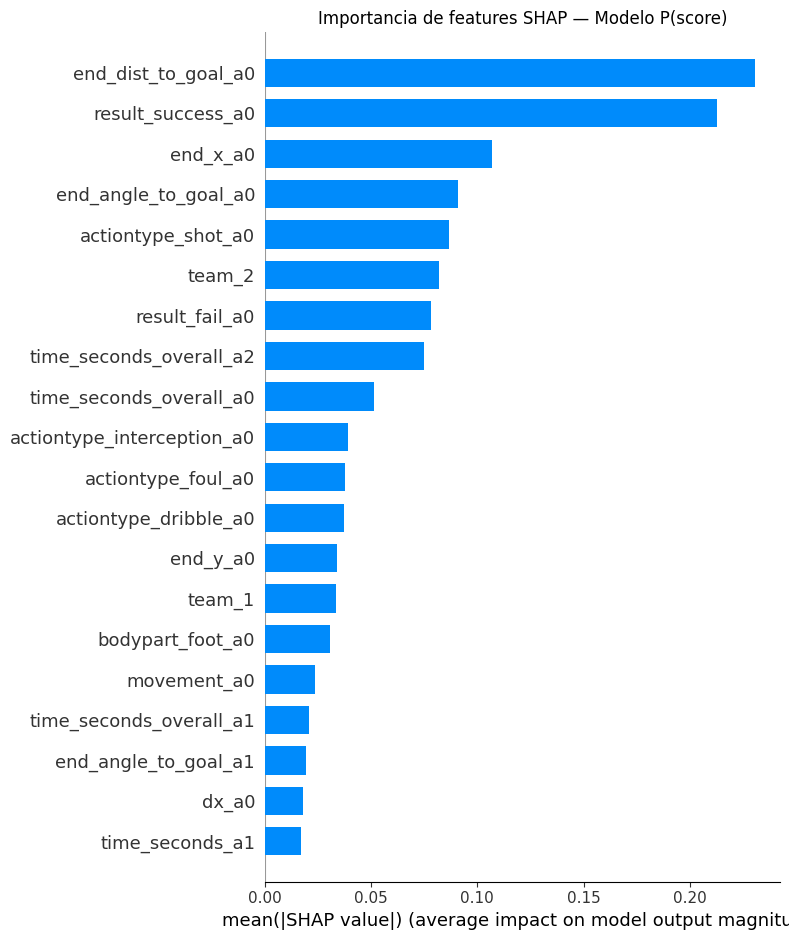

In [25]:
# Calculamos SHAP values para el modelo de scoring
print('Calculando SHAP values...')

# Muestra representativa (SHAP es costoso en datasets grandes)
sample_idx = np.random.choice(len(X_vaep), min(2000, len(X_vaep)), replace=False)
X_sample = X_vaep.iloc[sample_idx]

explainer = shap.TreeExplainer(model_score)
shap_values = explainer.shap_values(X_sample)

# Summary plot — las features más importantes globalmente
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_sample, 
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('Importancia de features SHAP — Modelo P(score)', fontsize=12)
plt.tight_layout()
plt.show()

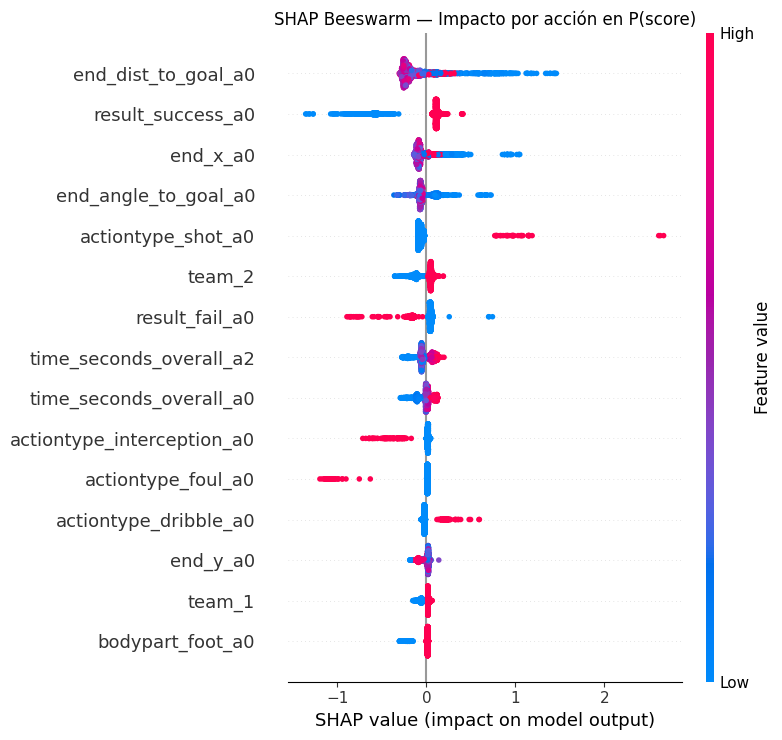

In [26]:
# SHAP Beeswarm plot — distribución del impacto
plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_values, X_sample,
    max_display=15,
    show=False
)
plt.title('SHAP Beeswarm — Impacto por acción en P(score)', fontsize=12)
plt.tight_layout()
plt.show()

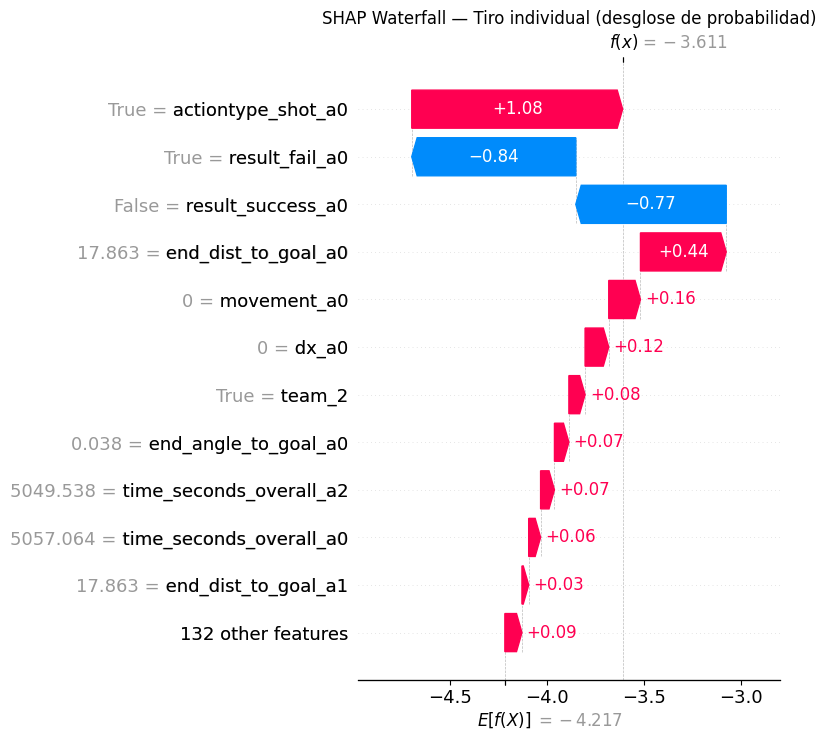

In [27]:
# SHAP waterfall para una acción específica (por ejemplo, un gol o tiro)
shot_names = ["shot", "shot_penalty", "penalty_shot", "shot_freekick", "freekick_shot"]
shot_idx = X_sample.index[
    df_vaep.loc[X_sample.index, "type_name"].isin(shot_names)
].tolist()

if len(shot_idx) > 0:
    idx = shot_idx[0]
    relative_idx = X_sample.index.get_loc(idx)
    
    exp_val = explainer.expected_value
    if isinstance(exp_val, (list, np.ndarray)):
        exp_val = float(exp_val[1] if len(exp_val) > 1 else exp_val[0])
    
    shap_exp = shap.Explanation(
        values=shap_values[relative_idx],
        base_values=exp_val,
        data=X_sample.iloc[relative_idx].values,
        feature_names=X_sample.columns.tolist()
    )
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_exp, max_display=12, show=False)
    plt.title("SHAP Waterfall — Tiro individual (desglose de probabilidad)", fontsize=12)
    plt.tight_layout()
    plt.show()


## 4. Comparación VAEP vs xT

Ambos frameworks valoran acciones, pero con enfoques distintos.
Analizamos en qué casos difieren más.

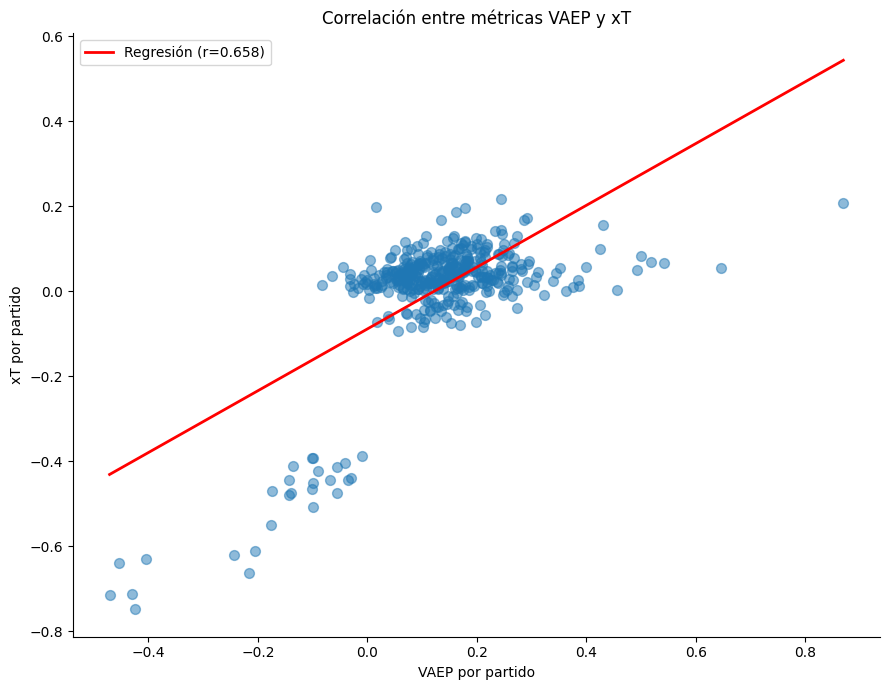

Correlación Pearson VAEP-xT: 0.6584

¿Por qué hay discrepancias? VAEP incluye valor defensivo, xT solo valora el movimiento del balón.


In [28]:
# Merge de rankings VAEP y xT
comparison = vaep_by_player.merge(
    xt_by_player[['player_id', 'xT_p90']],
    on='player_id', how='inner'
)

# Correlación entre ambas métricas
corr = comparison[['vaep_p90', 'xT_p90']].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(comparison['vaep_p90'], comparison['xT_p90'], alpha=0.5, s=50)
# Línea de tendencia
m, b = np.polyfit(comparison['vaep_p90'], comparison['xT_p90'], 1)
x_line = np.linspace(comparison['vaep_p90'].min(), comparison['vaep_p90'].max(), 100)
ax.plot(x_line, m*x_line + b, color='red', linewidth=2, label=f'Regresión (r={corr:.3f})')

ax.set_xlabel('VAEP por partido')
ax.set_ylabel('xT por partido')
ax.set_title('Correlación entre métricas VAEP y xT')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Correlación Pearson VAEP-xT: {corr:.4f}')
print('\n¿Por qué hay discrepancias? VAEP incluye valor defensivo, xT solo valora el movimiento del balón.')

## PARTE B — Aprendizaje No Supervisado

## 5. Clustering de jugadores

Queremos identificar perfiles de juego de manera automática, sin etiquetas previas.
Esto permite descubrir patrones emergentes y similitudes entre jugadores.

In [29]:
# Construcción del perfil de cada jugador
# Usamos distribución de tipos de acción como vector de características

# Pivot: jugador × tipo de acción
action_profile = df_vaep.groupby(
    ['player_id', 'type_name']
).size().unstack(fill_value=0)

# Filtramos jugadores con suficientes acciones
min_actions = 100
action_profile = action_profile[action_profile.sum(axis=1) >= min_actions]

# Normalizamos: proporción de cada tipo de acción
action_profile_norm = action_profile.div(action_profile.sum(axis=1), axis=0)

# Añadimos métricas de valor
vaep_feats = vaep_by_player[
    vaep_by_player['player_id'].isin(action_profile.index)
].set_index('player_id')[['vaep_p90', 'off_total', 'def_total']]

# Merge del perfil completo
player_vectors = action_profile_norm.join(vaep_feats, how='inner')
player_vectors = player_vectors.fillna(0)

print(f'Jugadores para clustering: {len(player_vectors)}')
print(f'Dimensiones del vector: {player_vectors.shape[1]}')

Jugadores para clustering: 409
Dimensiones del vector: 21


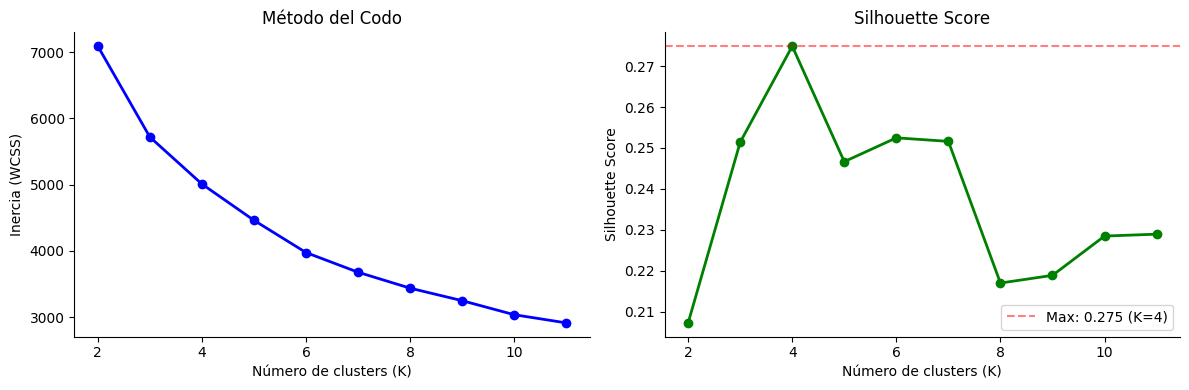


K óptimo por Silhouette: 4


In [30]:
# Estandarización antes de clustering
scaler = StandardScaler()
X_cluster = scaler.fit_transform(player_vectors)

# Método del codo para elegir K
inertias = []
silhouettes = []
K_range = range(2, 12)

from sklearn.metrics import silhouette_score

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels_k, sample_size=min(1000, len(X_cluster))))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Método del Codo')
axes[0].spines[['top','right']].set_visible(False)

axes[1].plot(K_range, silhouettes, 'go-', linewidth=2)
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].axhline(max(silhouettes), color='red', linestyle='--', alpha=0.5,
                label=f'Max: {max(silhouettes):.3f} (K={K_range.start + silhouettes.index(max(silhouettes))})')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

OPTIMAL_K = K_range.start + silhouettes.index(max(silhouettes))
print(f'\nK óptimo por Silhouette: {OPTIMAL_K}')

In [31]:
# Clustering final con K óptimo
km_final = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=20)
cluster_labels = km_final.fit_predict(X_cluster)

player_vectors['cluster'] = cluster_labels

print('Jugadores por cluster:')
print(player_vectors['cluster'].value_counts().sort_index())

Jugadores por cluster:
cluster
0     71
1    209
2     28
3    101
Name: count, dtype: int64


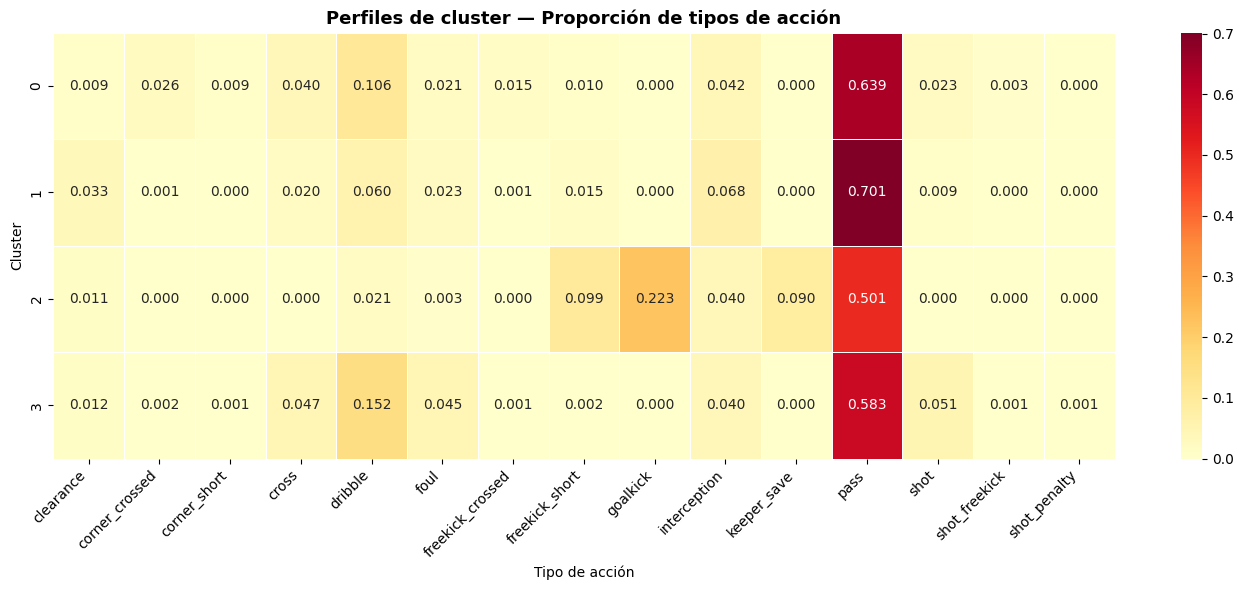

In [32]:
# Caracterización de cada cluster
cluster_profiles = player_vectors.groupby('cluster').mean()

# Heatmap de perfiles
action_cols = [c for c in player_vectors.columns if c not in ['cluster', 'vaep_p90', 'off_total', 'def_total']]

fig, ax = plt.subplots(figsize=(14, OPTIMAL_K + 2))
sns.heatmap(
    cluster_profiles[action_cols[:15]],  # Primeras 15 acciones
    annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=0.5, ax=ax
)
ax.set_title('Perfiles de cluster — Proporción de tipos de acción', fontsize=13, fontweight='bold')
ax.set_xlabel('Tipo de acción')
ax.set_ylabel('Cluster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Visualización con UMAP

UMAP (Uniform Manifold Approximation and Projection) es una técnica de reducción de
dimensionalidad superior a t-SNE para grandes datasets. Preserva mejor la estructura global.

Computando UMAP...


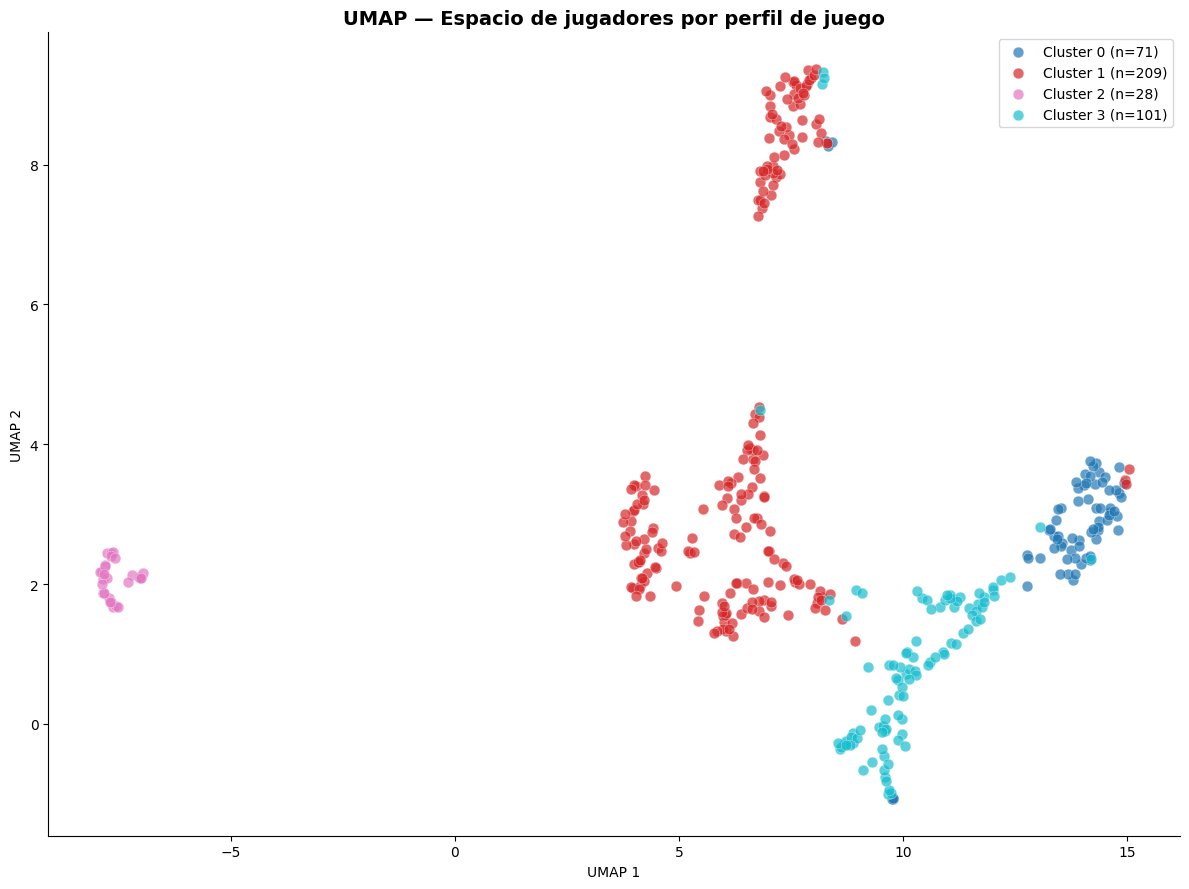

In [33]:
# Reducción dimensional con UMAP
print('Computando UMAP...')
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=RANDOM_STATE
)
embedding = reducer.fit_transform(X_cluster)

df_viz = pd.DataFrame({
    'umap_1': embedding[:, 0],
    'umap_2': embedding[:, 1],
    'cluster': cluster_labels,
    'player_id': player_vectors.index
})

# Paleta de colores por cluster
cluster_colors = plt.get_cmap('tab10', OPTIMAL_K)

fig, ax = plt.subplots(figsize=(12, 9))
for k in range(OPTIMAL_K):
    mask_k = df_viz['cluster'] == k
    ax.scatter(
        df_viz.loc[mask_k, 'umap_1'],
        df_viz.loc[mask_k, 'umap_2'],
        c=[cluster_colors(k)],
        s=60, alpha=0.7, edgecolors='white', linewidth=0.3,
        label=f'Cluster {k} (n={mask_k.sum()})'
    )

ax.set_title('UMAP — Espacio de jugadores por perfil de juego', fontsize=14, fontweight='bold')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(loc='upper right', fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 7. Sistema de Scouting por Similitud

El clustering nos da perfiles generales, pero para scouting necesitamos
identificar jugadores similares de forma más precisa.

In [34]:
def find_similar_players(player_id: int, 
                         player_matrix: np.ndarray,
                         player_ids: pd.Index,
                         top_n: int = 10) -> pd.DataFrame:
    """
    Encuentra los N jugadores más similares basado en similitud coseno.
    
    Parámetros
    ----------
    player_id     : ID del jugador de referencia
    player_matrix : matriz normalizada de features
    player_ids    : índice con IDs de jugadores
    top_n         : número de similares a retornar
    """
    if player_id not in player_ids:
        raise ValueError(f"Jugador {player_id} no encontrado en la matriz")
        
    idx = player_ids.get_loc(player_id)
    player_vec = player_matrix[idx].reshape(1, -1)
    
    # Similitud coseno con todos los jugadores
    similarities = cosine_similarity(player_vec, player_matrix)[0]
    
    # Ordenamos y excluimos al propio jugador
    sim_df = pd.DataFrame({
        "player_id": player_ids,
        "similarity": similarities
    })
    sim_df = sim_df[sim_df["player_id"] != player_id]
    sim_df = sim_df.sort_values("similarity", ascending=False).head(top_n)
    sim_df["rank"] = range(1, len(sim_df) + 1)
    sim_df["jugador"] = sim_df["player_id"].map(player_names).fillna(sim_df["player_id"].astype(str))
    
    return sim_df

# Ejemplo: encontrar jugadores similares al mejor jugador por VAEP
best_row = vaep_by_player.sort_values("vaep_p90", ascending=False).iloc[0]
best_player_id = int(best_row["player_id"])
best_player_name = best_row.get("jugador", str(best_player_id))
print(f"Buscando jugadores similares a: {best_player_name} (ID: {best_player_id})")

try:
    similar = find_similar_players(
        best_player_id,
        X_cluster,
        player_vectors.index,
        top_n=10
    )
    print("\n10 jugadores más similares:")
    print(similar[["rank", "player_id", "jugador", "similarity"]].to_string(index=False))
except ValueError as e:
    print(f"Nota: {e}")


Buscando jugadores similares a: L. Messi (ID: 3359)

10 jugadores más similares:
 rank  player_id           jugador  similarity
    1       7972         L. Suárez    0.907103
    2       3682      A. Griezmann    0.870602
    3       3322 Cristiano Ronaldo    0.849124
    4       3840        Iago Aspas    0.824073
    5       8278           G. Bale    0.775241
    6      70129           Rodrigo    0.743096
    7       4379    Jonathan Viera    0.716834
    8     280383         E. Bardhi    0.709558
    9       5400     Gerard Moreno    0.659043
   10     278278             Munir    0.582168


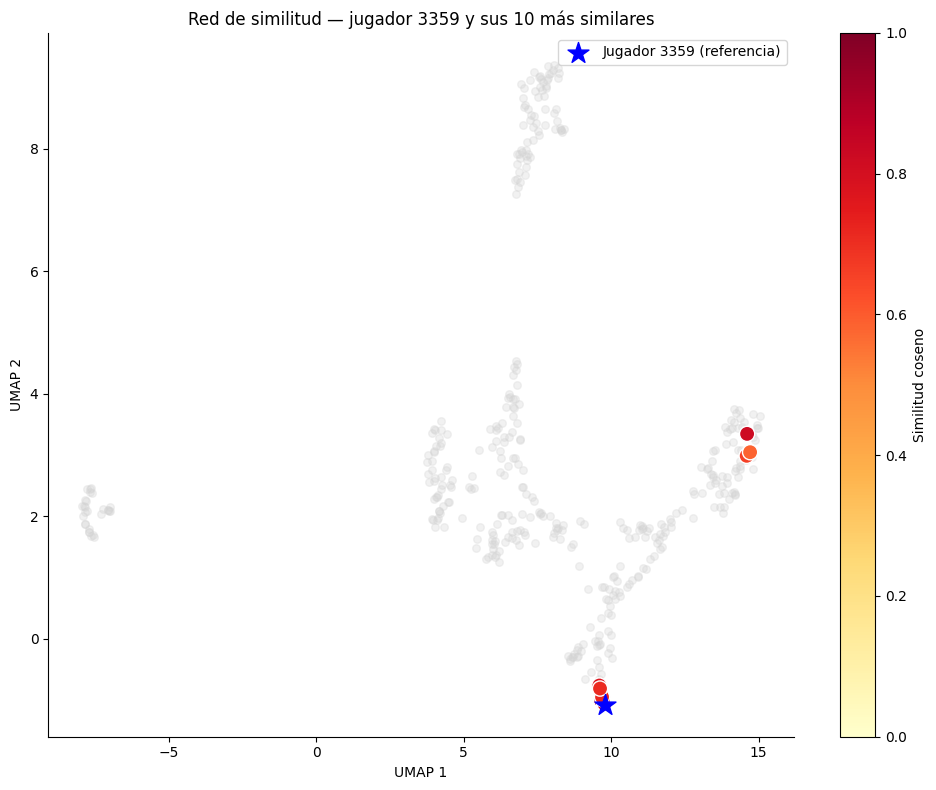

In [35]:
# Visualización de similitud en el espacio UMAP
def plot_player_network(player_id: int, similar_df: pd.DataFrame, 
                        umap_df: pd.DataFrame):
    """
    Visualiza al jugador y sus más similares en el espacio UMAP.
    """
    fig, ax = plt.subplots(figsize=(10, 8))

    # Todos los jugadores (fondo)
    ax.scatter(
        umap_df['umap_1'], umap_df['umap_2'],
        c='lightgray', s=30, alpha=0.3, zorder=1
    )

    # Jugadores similares
    sim_ids = similar_df['player_id'].tolist()
    sim_points = umap_df[umap_df['player_id'].isin(sim_ids)]
    sc = ax.scatter(
        sim_points['umap_1'], sim_points['umap_2'],
        c=similar_df['similarity'].tolist()[:len(sim_points)],
        cmap='YlOrRd', vmin=0, vmax=1,
        s=120, zorder=3, edgecolors='white', linewidth=1
    )
    plt.colorbar(sc, label='Similitud coseno')

    # Jugador de referencia
    ref_point = umap_df[umap_df['player_id'] == player_id]
    if len(ref_point) > 0:
        ax.scatter(
            ref_point['umap_1'], ref_point['umap_2'],
            c='blue', s=250, marker='*', zorder=5,
            label=f'Jugador {player_id} (referencia)'
        )

    ax.set_title(f'Red de similitud — jugador {player_id} y sus 10 más similares', fontsize=12)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend()
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.show()

try:
    plot_player_network(int(best_player_id), similar, df_viz)
except Exception as e:
    print(f'Visualización no disponible: {e}')

## 8. Dashboard final de rankings

In [36]:
# Merge de todas las métricas
cluster_df = player_vectors[["cluster"]].reset_index()
if "player_id" not in cluster_df.columns:
    cluster_df = cluster_df.rename(columns={"index": "player_id"})

final_rankings = vaep_by_player.merge(
    xt_by_player[["player_id", "xT_p90", "xT_total"]],
    on="player_id", how="inner"
).merge(
    cluster_df,
    on="player_id", how="left"
)

# Rankeo en cada métrica
final_rankings["rank_vaep"] = final_rankings["vaep_p90"].rank(ascending=False).astype(int)
final_rankings["rank_xt"]   = final_rankings["xT_p90"].rank(ascending=False).astype(int)
final_rankings["rank_avg"]  = ((final_rankings["rank_vaep"] + final_rankings["rank_xt"]) / 2)

print("=== TABLA DE RANKINGS FINALES ===")
cols = ["player_id", "jugador", "vaep_p90", "xT_p90", "rank_vaep", "rank_xt", "rank_avg", "cluster", "games"]
cols = [c for c in cols if c in final_rankings.columns]
print(
    final_rankings.sort_values("rank_avg")
    .head(20)[cols]
    .to_string(index=False)
)


=== TABLA DE RANKINGS FINALES ===
 player_id           jugador  vaep_p90   xT_p90  rank_vaep  rank_xt  rank_avg  cluster  games
      3359          L. Messi  0.869927 0.207624          1        2       1.5      0.0     36
      3676      Illarramendi  0.430044 0.156346          8        9       8.5      1.0     36
     14723          T. Kroos  0.291136 0.171995         25        6      15.5      0.0     27
      3310           Marcelo  0.286700 0.168059         26        8      17.0      1.0     28
    225089 José Luis Morales  0.273652 0.130053         30       15      22.5      3.0     35
      3802 Philippe Coutinho  0.425947 0.100487          9       36      22.5      0.0     18
      4379    Jonathan Viera  0.243815 0.217195         54        1      27.5      0.0     23
      3563              Isco  0.268313 0.112895         34       23      28.5      0.0     30
      4780       David Juncà  0.245866 0.134780         50       12      31.0      1.0     14
    278289         Odriozo

In [37]:
# Exportamos resultados finales
output_rankings = './rankings_jugadores_PL_2017.csv'
final_rankings.to_csv(output_rankings, index=False)
print(f'Rankings guardados en: {output_rankings}')

Rankings guardados en: ./rankings_jugadores_PL_2017.csv


## 9. Actividades propuestas

### Ejercicio 1 — Grilla xT extendida
Implementá la grilla xT con resolución más alta (32×24) y compará los resultados.
¿Mayor resolución mejora la métrica o genera overfitting? Usá validación cruzada por partido.

### Ejercicio 2 — VAEP con LightGBM
Entrenaste el modelo VAEP con XGBoost. Ahora reemplazalo con LightGBM.
Compará: tiempo de entrenamiento, AUC, Brier Score y los 10 mejores jugadores por VAEP.
¿Cambia el ranking? ¿En qué porcentaje?

### Ejercicio 3 — Mapas Espaciales de Generación de Valor (Action-Value Flow)
Los números agregados (como el VAEP total o p90) resumen el rendimiento general, pero las visualizaciones espaciales revelan *dónde* y *cómo* se genera ese valor en el campo de juego. Construí una visualización de alto impacto visual para incorporar en tu presentación final:

1. **Mapa de Calor / Grilla Binned de Valor**: Representá sobre el campo (`mplsoccer.Pitch`) la densidad o grilla binned de valor generado (VAEP u ofensivo/defensivo) de un equipo o jugador clave, identificando sus "zonas calientes" de generación de peligro.
2. **Flujo de Acciones de Alto Impacto (Action Flow)**: Para uno o dos jugadores destacados (ej. Kevin De Bruyne, Mohamed Salah, Eden Hazard), filtrá sus acciones con mayor VAEP positivo (top N o percentil 95+) y graficalas como vectores/flechas (`pitch.arrows` o `pitch.lines`), coloreadas por el valor de la acción (usando un colormap continuo como `viridis` o `plasma`) o por tipo de acción (pase, regate, recuperación).
3. **Comparativa Visual Cara a Cara (Side-by-Side)**: Realizá una figura comparativa de dos jugadores con roles similares o rivales para mostrar las diferencias espaciales en su toma de decisiones y zonas de influencia.
4. **Diseño y Estética para la Presentación**: Cuidá la estética visual (paleta de colores profesional, tema pitch/dark, leyendas claras, anotación de VAEP p90 y métricas clave) para que sea un slide visualmente impactante y autoexplicativo en la presentación final.

### Ejercicio 4 — Clustering por liga
Aplicá el pipeline de clustering a todas las ligas disponibles.
¿Los mismos perfiles aparecen en todas las ligas? ¿Hay perfiles de juego únicos
de alguna liga en particular?

### Ejercicio 5 — Sistema de scouting
Construí un sistema de scouting que dado un jugador 'objetivo' (player_id):
1. Muestre su perfil en radar (métricas normalizadas por posición)
2. Identifique sus 5 jugadores más similares
3. Compare VAEP y xT del objetivo vs. similares
4. Indique si hay jugadores similares con mayor VAEP (posibles mejoras de mercado)

Aplicalo para encontrar reemplazante de algún jugador histórico de la temporada.

---
**Entregable**: Notebook completo con pipeline VAEP/xT + análisis de clustering + sistema de scouting documentado.